## Setup

In [1]:
# INDIA_PROJECTED_CRS = "24378"

In [2]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [3]:
# general
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
from tqdm.notebook import tqdm

# for plotting and coloring
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import math
import matplotlib.cm

# for handling S2 cells and downloading VIDA data 
import boto3
from s2cell.s2cell import lat_lon_to_cell_id
import s2sphere
from shapely.geometry import Polygon

gpd.options.io_engine = "pyogrio"

In [4]:
from gridsample.utils import create_ids, create_gmap_links, save_shapefiles
# from gridsample.mapping import create_interactive_map

In [5]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "01. Raw Data"
CLEANED_DATA_DIR = DATA_DIR / "02. Intermediate Outputs"
OUTPUT_DATA_DIR = DATA_DIR / "03. Final Outputs"
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
def generate_colormap(N):
    arr = np.arange(N)/N
    N_up = int(math.ceil(N/7)*7)
    arr.resize(N_up)
    arr = arr.reshape(7,N_up//7).T.reshape(-1)
    ret = matplotlib.cm.hsv(arr)
    n = ret[:,3].size
    a = n//2
    b = n-a
    
    # Create arrays of exactly matching sizes
    for i in range(3):
        ret[0:a,i] *= np.linspace(0.2, 1, a)
    ret[a:,3] *= np.linspace(1, 0.3, b)
    
    return ret[:N]  # Return only the requested number of colors

## 0. Load boundaries

In [7]:
# get all filepaths that end in `gpkg` inside the RAW_DATA_DIR / 0.1. MapSolve Boundaries
boundaries_dir = RAW_DATA_DIR / "01. MapSolve Boundaries"
gpkg_files_all = list(boundaries_dir.glob("**/*.gpkg"))
gpkg_files_all = [f for f in gpkg_files_all if f.is_file()]
# # drop any with the word "Sub-District" in the filename
# gpkg_files_VTW = [f for f in gpkg_files_all if "Sub-District" not in f.name]
# load all shapes into one gdf
gdf_list = []
for filepath in gpkg_files_all:
    gdf_list.append(gpd.read_file(filepath))
gdf = pd.concat(gdf_list, ignore_index=True).to_crs(4326)

<Axes: >

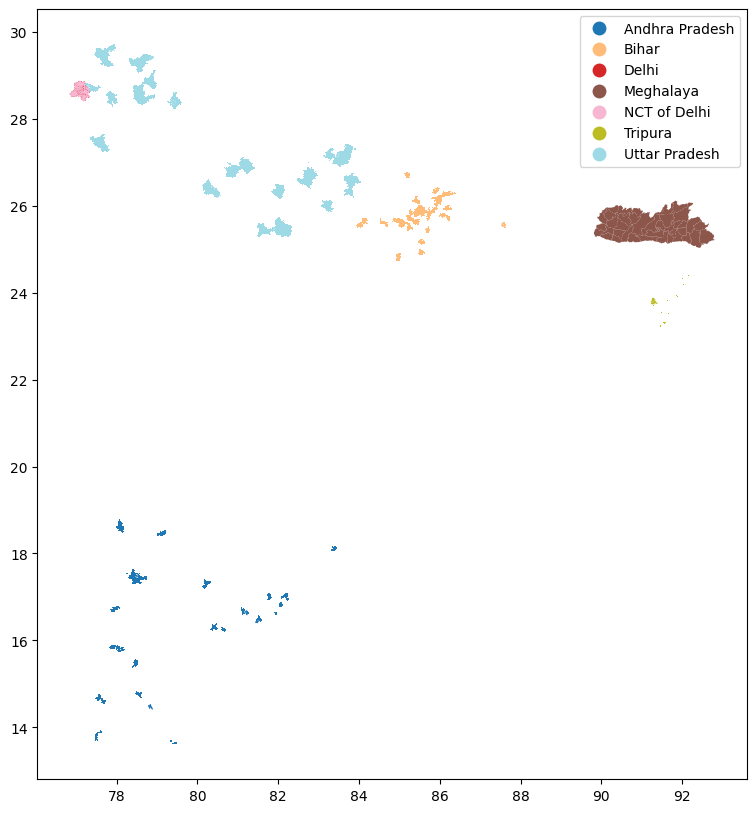

In [8]:
gdf.plot(column="State_N", legend=True, figsize=(10, 10), cmap="tab20")

In [9]:
# boundaries_gdf = gpd.read_file(RAW_DATA_DIR / "01. MapSolve Boundaries/State_C_7/State_C_7_Sub-District.gpkg")
# boundaries_gdf = boundaries_gdf.to_crs(4326)

# boundaries_gdf.plot(
#     column="PCA_ID",
#     figsize=(6, 6),
#     cmap=ListedColormap(generate_colormap(len(boundaries_gdf))),
#     edgecolor="black",
# )
# # create_interactive_map(boundaries_gdf, point_id_col="PCA_ID")


In [10]:
# boundaries_gdf = gpd.read_file(RAW_DATA_DIR / "01. MapSolve Boundaries/State_C_7/State_C_7.gpkg")
# boundaries_gdf = boundaries_gdf.to_crs(4326)

# boundaries_gdf.plot(
#     column="PCA_ID",
#     figsize=(6, 6),
#     cmap=ListedColormap(generate_colormap(len(boundaries_gdf))),
#     edgecolor="black",
# )
# # create_interactive_map(boundaries_gdf, point_id_col="PCA_ID")

# 0.5 Load sampled wards information

In [11]:
# load the merged wards data
merged_df = pd.read_csv(CLEANED_DATA_DIR / "Merged Wards with Quality Checks.csv")

In [12]:
merged_df

,State,State_Name,District,District_Name,Subdistrict,Subd_Name,TownVillage,UrbanWardVillage,WardVillage_Name,TRU,...,Sampled for IFS,Ward Boundary Available with MapSolve,_merge,State Shared by MapSolve,State Changed,PCA_ID,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State
0,2,HIMACHAL PRADESH,33,Shimla,182,Shimla (urban),800137,1,Shimla (M Corp.) WARD NO.-0001,Urban,...,Yes,No,right_only,False,No,800137-1,False,False,False,BAD - No boundary(s) given
1,2,HIMACHAL PRADESH,33,Shimla,182,Shimla (urban),800137,16,Shimla (M Corp.) WARD NO.-0016,Urban,...,No,No,left_only,False,No,800137-16,False,False,False,BAD - No boundary(s) given
2,2,HIMACHAL PRADESH,33,Shimla,182,Shimla (urban),800137,19,Shimla (M Corp.) WARD NO.-0019,Urban,...,Yes,No,right_only,False,No,800137-19,False,False,False,BAD - No boundary(s) given
3,2,HIMACHAL PRADESH,33,Shimla,182,Shimla (urban),800137,22,Shimla (M Corp.) WARD NO.-0022,Urban,...,No,No,left_only,False,No,800137-22,False,False,False,BAD - No boundary(s) given
4,2,HIMACHAL PRADESH,33,Shimla,182,Shimla (urban),800137,23,Shimla (M Corp.) WARD NO.-0023,Urban,...,No,No,left_only,False,No,800137-23,False,False,False,BAD - No boundary(s) given
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1014,90,TELANGANA,537,Rangareddy,4523,Ghatkesar,574173,1,Peerzadguda (CT) WARD NO.-0001,Urban,...,No,No,left_only,True,Previously Andhra Pradesh,574173-1,False,True,False,GOOD - Town/Village boundary given as expected
1015,90,TELANGANA,538,Mahbubnagar,4568,Mahbubnagar,802922,4,Mahbubnagar (M) WARD NO.-0004,Urban,...,Yes,No,both,True,Previously Andhra Pradesh,802922-4,False,True,False,GOOD - Town/Village boundary given as expected
1016,90,TELANGANA,541,Khammam,4757,Khammam (Urban),579683,0,V. Venkatayapalem,Rural,...,Yes,No,right_only,True,Previously Andhra Pradesh,579683-0,False,True,False,GOOD - Town/Village boundary given as expected
1017,90,TELANGANA,541,Khammam,4757,Khammam (Urban),579685,1,Khanapuram Haveli (CT) WARD NO.-0001,Urban,...,No,No,left_only,True,Previously Andhra Pradesh,579685-1,False,True,False,GOOD - Town/Village boundary given as expected


In [13]:
# boundaries_gdf = boundaries_gdf.merge(
#     merged_df[["PCA_ID", "Ward_ID", "Ward_Name"]],
#     on="PCA_ID",
#     how=...
# )

## 1. Download rooftops

### Functions

#### S2 cell shapes

In [14]:
def s2_cell_id_to_shape(s2_cell_id):
    """
    Convert an S2 cell ID to a shapely polygon.
    
    Parameters:
    - s2_cell_id (int): The S2 cell ID
    
    Returns:
    - shapely.geometry.Polygon: Polygon representing the S2 cell
    """
    # Convert string to int if necessary
    if isinstance(s2_cell_id, str):
        s2_cell_id = int(s2_cell_id)
    
    # Create an S2 cell from the ID
    cell = s2sphere.CellId(s2_cell_id)
    cell = s2sphere.Cell(cell)
    
    # Extract the vertices of the cell
    vertices = []
    for i in range(4):
        vertex = cell.get_vertex(i)
        lat_lng = s2sphere.LatLng.from_point(vertex)
        vertices.append((lat_lng.lng().degrees, lat_lng.lat().degrees))
    
    # Close the polygon by repeating the first vertex
    vertices.append(vertices[0])
    
    # Create a shapely polygon
    return Polygon(vertices)

def s2_cell_ids_to_shapes_gdf(s2_cell_ids):
    """
    Convert a list of S2 cell IDs to a GeoDataFrame with polygon geometries.
    
    Parameters:
    - s2_cell_ids (list): List of S2 cell IDs
    
    Returns:
    - geopandas.GeoDataFrame: GeoDataFrame with S2 cells as polygons
    """
    geometries = []
    for s2_id in s2_cell_ids:
        polygon = s2_cell_id_to_shape(s2_id)
        geometries.append(polygon)
    
    return gpd.GeoDataFrame(
        {'s2_cell_id': s2_cell_ids, 'geometry': geometries},
        crs="EPSG:4326"
    )

#### Find IDs of overlapping S2 cells

In [15]:
def get_s2_cell_ids_from_points(points, level=6) -> list[int]:
    """
    Get S2 cell IDs for the given points at the specified level.
    """
    # check if crs is set to WGS84 (EPSG:4326)
    if points.crs is None or points.crs.to_string() != "EPSG:4326":
        raise ValueError("Points GeoDataFrame must be in WGS84 (EPSG:4326) CRS.")
    
    # convert points to S2 cell IDs
    s2_cell_id_list = points.geometry.apply(lambda geom: lat_lon_to_cell_id(geom.y, geom.x, level))
    s2_cell_ids = s2_cell_id_list.unique().tolist()

    return s2_cell_ids


def get_s2_cell_ids(gdf, level=6) -> list[int]:
    """
    Get S2 cell IDs of S2 cells that overlap the given GeoDataFrame at the specified level.

    Iteratively checks if any area is not covered by an S2 cell and continues until all areas are covered.

    Parameters:
    - gdf: GeoDataFrame in WGS84 (EPSG:4326) CRS
    - level: int

    Returns:
    - list[int]: List of S2 cell IDs
    """

    # check if crs is set to WGS84 (EPSG:4326)
    if gdf.crs is None or gdf.crs.to_string() != "EPSG:4326":
        raise ValueError("GeoDataFrame must be in WGS84 (EPSG:4326) CRS.")

    # generate initial S2 cell IDs from the GeoDataFrame centroids
    points = gdf.geometry.centroid.to_frame(name="geometry")
    s2_cell_ids = get_s2_cell_ids_from_points(points, level=level)

    # get initial S2 cell shapes and check for full coverage
    s2_cell_shapes = s2_cell_ids_to_shapes_gdf(s2_cell_ids)
    leftover_shapes = gdf.difference(s2_cell_shapes.unary_union)
    leftover_shapes = leftover_shapes[~leftover_shapes.is_empty]

    print(f"Shapes with spillover after round 1: {len(leftover_shapes)}")

    step = 2
    while len(leftover_shapes) > 0:
        # get new s2 cell IDs from the leftover shapes
        points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")
        s2_cell_ids_new = get_s2_cell_ids_from_points(points_new, level=level)

        # get new s2 cell shapes
        s2_cell_shapes = s2_cell_ids_to_shapes_gdf(s2_cell_ids_new)
        leftover_shapes = leftover_shapes.difference(s2_cell_shapes.unary_union)
        leftover_shapes = leftover_shapes[~leftover_shapes.is_empty]

        # add new s2 cell IDs to the existing list
        s2_cell_ids = s2_cell_ids + s2_cell_ids_new

        print(f"Shapes with spillover after round {step}: {len(leftover_shapes)}")
        step += 1

    return s2_cell_ids

#### Auto-download rooftop data by S2 cell ID

In [16]:
def download_VIDA_rooftops_data_by_s2_single(s2_cell_id: int, country_iso_code: str, target_data_dir: Path) -> None:
    """
    Download S2 rooftops data for a given S2 cell ID from the VIDA S3 bucket. URL:
    https://beta.source.coop/vida/google-microsoft-open-buildings/geoparquet/by_country_s2/country_iso=IND/
    """

    s2_rooftops_path = target_data_dir / f"{s2_cell_id}.parquet"

    if s2_rooftops_path.exists():
        print(f"File {s2_cell_id} already exists.")
    else:
        print(f"Downloading file for S2 cell ID: {s2_cell_id}")
        s2_rooftops_path.parent.mkdir(parents=True, exist_ok=True)
        s3 = boto3.client("s3", endpoint_url="https://data.source.coop")
        try:
            s3.download_file(
                "vida",
                f"google-microsoft-open-buildings/geoparquet/by_country_s2/country_iso={country_iso_code}/{s2_cell_id}.parquet",
                str(s2_rooftops_path),
            )
            print(f"File {s2_cell_id} downloaded.")
        except Exception as e:
            raise RuntimeError(f"Failed to download file for S2 cell ID {s2_cell_id}: {e}")

def download_VIDA_rooftops_data_by_s2(
    s2_cell_ids: list[int], country_iso_code: str, target_data_dir: Path
) -> None:
    """
    Download S2 rooftops data for multiple S2 cell IDs

    Parameters:
    - s2_cell_ids: list of S2 cell IDs
    - country_iso_code: ISO code of the country (e.g., "IND" for India)
    - target_data_dir: directory to save the downloaded data
    """

    for s2_cell_id in tqdm(s2_cell_ids, desc="Downloading rooftops by S2 cell"):
        download_VIDA_rooftops_data_by_s2_single(s2_cell_id, country_iso_code, target_data_dir)

### Run

#### Identify S2 cell IDs

In [17]:
s2_cell_ids = get_s2_cell_ids(gdf) #get_s2_cell_ids(boundaries_gdf)
len(s2_cell_ids)

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_90550/1320069639.py:35: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points = gdf.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 1: 4
Shapes with spillover after round 2: 0


/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_90550/1320069639.py:48: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


44

#### Check if identified cells cover all areas of interest

In [18]:
s2_cells_gdf = s2_cell_ids_to_shapes_gdf(s2_cell_ids)

In [19]:
# Does the S2 cell cover the entire area of the boundaries?
uncovered_area = gdf.unary_union.difference(s2_cells_gdf.unary_union).area
print(f"{uncovered_area} square degrees area not covered by an S2 cell")

0.0 square degrees area not covered by an S2 cell


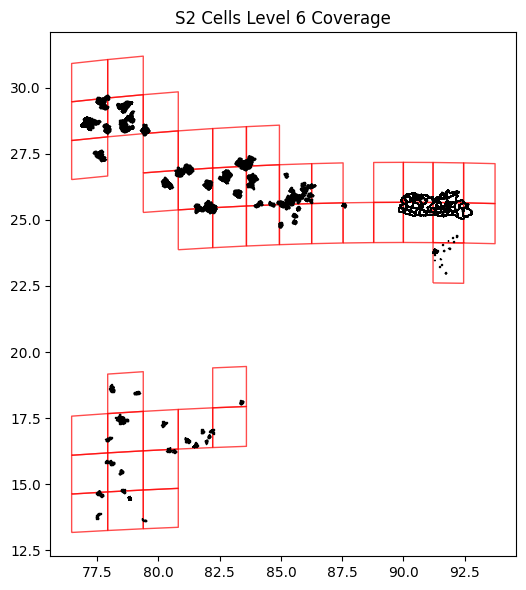

In [20]:
# Plot the S2 cells and the boundary
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
gdf.boundary.plot(ax=ax, color="black", linewidth=1)
s2_cells_gdf.plot(ax=ax, facecolor="none", edgecolor="red", alpha=0.7)
plt.title("S2 Cells Level 6 Coverage")
plt.tight_layout()
plt.show()

In [21]:
s2_cells_gdf_w_state = (
    s2_cells_gdf.sjoin(
        gdf[["State_N", "geometry"]], how="inner", predicate="intersects"
    )
    .drop(columns="index_right")
    .drop_duplicates()
)

#### Download the S2 cells

In [22]:
download_VIDA_rooftops_data_by_s2(s2_cell_ids, "IND", RAW_DATA_DIR / "02. Rooftop Data")

File 4194821577918906368 already exists.
File 4195384527872327680 already exists.
File 4195947477825748992 already exists.
File 4194258627965485056 already exists.
File 4308537468510011392 already exists.
File 4309100418463432704 already exists.
File 4307974518556590080 already exists.
File 4200451077453119488 already exists.
File 4302345019022376960 already exists.
File 4301782069068955648 already exists.
File 4302907968975798272 already exists.
File 4301219119115534336 already exists.
File 4201014027406540800 already exists.
File 3985967145199599616 already exists.
File 3987655995059863552 already exists.
File 3985404195246178304 already exists.
File 4178496029269688320 already exists.
File 3988218945013284864 already exists.
File 3988781894966706176 already exists.
File 4175681279502581760 already exists.
File 4173992429642317824 already exists.
File 4148659681738358784 already exists.
File 4146970831878094848 already exists.
File 4174555379595739136 already exists.
File 41779330793

## 2. Load rooftops and match to areas

In [23]:
def get_matched_rooftop_centroids_from_s2_file(
    s2_cell_id: int, boundaries_gdf: gpd.GeoDataFrame
) -> gpd.GeoDataFrame:
    """
    Get rooftops from the S2 cell file that match the boundaries:
    1. loads the rooftops data for the specified S2 cell ID
    2. filters the rooftops to only those that intersect with the boundaries
    3. returns a GeoDataFrame of the matched rooftops centroids with unique IDs

    Parameters:
    - s2_cell_id (int): The S2 cell ID to filter rooftops for.
    - boundaries_gdf (gpd.GeoDataFrame): The GeoDataFrame containing the boundaries.
    """

    # load the rooftops data for the S2 cell
    s2_rooftops_path = RAW_DATA_DIR / "02. Rooftop Data" / f"{s2_cell_id}.parquet"
    s2_rooftops_gdf = gpd.read_parquet(s2_rooftops_path)

    # replace polygons with just the centroid of the rooftops
    s2_rooftop_centroids_gdf = s2_rooftops_gdf.set_geometry(
        s2_rooftops_gdf.geometry.centroid
    )

    # filter the boundaries dataset to only the shapes that overlap the S2 cell
    s2_cell_polygon = s2_cell_id_to_shape(s2_cell_id)
    boundaries_gdf_s2_overlap = boundaries_gdf[
        boundaries_gdf.intersects(s2_cell_polygon)
    ]

    # perform a spatial join to filter and add area metadata to the rooftops
    matched_rooftop_centroids_gdf = gpd.sjoin(
        s2_rooftop_centroids_gdf,
        boundaries_gdf_s2_overlap,
        how="inner",
        predicate="within",
    ).drop(columns=["index_right"])

    # add IDs to each rooftop
    matched_rooftop_centroids_gdf["s2_rooftop_id"] = create_ids(
        len(matched_rooftop_centroids_gdf), f"S2_{s2_cell_id}_ROOFTOP_"
    )

    return matched_rooftop_centroids_gdf

In [24]:
state_names = gdf["State_N"].unique()

In [25]:
state_names[6:]

array(['NCT of Delhi'], dtype=object)

In [ ]:
for state_name in tqdm(state_names[6:]):
    print(f"Processing state: {state_name}")

    # Filter the s2 cells and rooftops gdf to the current state
    s2_cell_ids = set(
        s2_cells_gdf_w_state[s2_cells_gdf_w_state["State_N"] == state_name][
            "s2_cell_id"
        ]
    )
    print(f"Number of S2 cells that overlap our shapes in {state_name}: {len(s2_cell_ids)}")
    gdf_subset = gdf[gdf["State_N"] == state_name]

    # Get matched rooftops for each S2 cell in the state
    matched_rooftop_centroids_gdf_list = []
    for s2_cell_id in tqdm(s2_cell_ids):
        matched_rooftop_centroids_gdf = get_matched_rooftop_centroids_from_s2_file(
            s2_cell_id, gdf_subset
        )
        matched_rooftop_centroids_gdf_list.append(matched_rooftop_centroids_gdf)
    matched_rooftop_centroids_gdf = pd.concat(
        matched_rooftop_centroids_gdf_list, ignore_index=True
    )
    matched_rooftop_centroids_gdf["State_N"] = state_name

    # Save the matched rooftops data
    save_shapefiles(
        matched_rooftop_centroids_gdf,
        CLEANED_DATA_DIR / "01. Matched Rooftop Data" / f"{state_name}",
        "matched_rooftops",
        ["parquet"],
    )

In [ ]:
matched_rooftop_centroids_gdf.sample(1000).plot(
    cmap=ListedColormap(generate_colormap(len(matched_rooftop_centroids_gdf))),
)

### Save to file

In [ ]:
save_shapefiles(
    matched_rooftop_centroids_gdf,
    CLEANED_DATA_DIR / "01. Matched Rooftop Data",
    "matched_rooftops_delhi_test",
    ["csv", "kml", "parquet"],
)

## 3. Sample rooftops

### Do the sampling

In [ ]:
NUM_ROOFTOPS_PER_AREA = 10

In [ ]:
sampled_rooftops = matched_rooftop_centroids_gdf.groupby("PCA_ID", group_keys=False).apply(
    lambda x: x.sample(n=min(NUM_ROOFTOPS_PER_AREA, x.shape[0]), random_state=42)
)

In [ ]:
print(len(sampled_rooftops))

In [ ]:
sampled_rooftops.plot(column="PCA_ID", figsize=(6, 6), cmap="tab20", edgecolor="black")

### Add sample-level rooftop numbering ID column

In [ ]:
# First, create a helper column to track the sequence within each group
sampled_rooftops = sampled_rooftops.sort_values('PCA_ID')
sampled_rooftops['rooftop_number'] = sampled_rooftops.groupby('PCA_ID').cumcount() + 1

# Then use this column to create your ID
sampled_rooftops["sample_rooftop_id"] = sampled_rooftops.apply(
    lambda row: f"PCA_ID_{row['PCA_ID']}_ROOFTOP_{row['rooftop_number']}", axis=1
)

# Optionally drop the helper column if not needed
sampled_rooftops = sampled_rooftops.drop(columns=['rooftop_number'])

### Add gmap link

In [ ]:
sampled_rooftops["latitude"] = sampled_rooftops.geometry.y
sampled_rooftops["longitude"] = sampled_rooftops.geometry.x
sampled_rooftops["gmap_link"] = create_gmap_links(
    df=sampled_rooftops,
    lat_name="latitude",
    lon_name="longitude",
)

### Select only useful columns

In [ ]:
sampled_rooftops = sampled_rooftops[
    [
        "sample_rooftop_id",
        "latitude",
        "longitude",
        "gmap_link",
        "s2_rooftop_id",
        "s2_id",
        "UID",
        "PCA_ID",
        "State_C",
        "State_N",
        "Ward_C",
        "Dist_C",
        "Dist_N",
        "SubDist_C",
        "SubDist_N",
        "TV_C",
        "TV_N",
        "TOT_P",
        "geometry",
    ]
]

In [ ]:
sampled_rooftops.head()

### Save sampled data

In [ ]:
save_shapefiles(
    sampled_rooftops,
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_delhi_test",
    ["csv", "parquet", "kml"],
)

## Scraps

In [ ]:
# def create_grid_points(gdf, cell_size=0.05) -> gpd.GeoDataFrame:
#     """
#     Create a grid of points within the bounds of the unary geometry of the GeoDataFrame.

#     Parameters:
#     - gdf: GeoDataFrame
#     - cell_size: float, size of the grid cells

#     Returns:
#     - GeoDataFrame with grid points
#     """

#     bounds = gdf.unary_union.bounds
#     min_lon, min_lat, max_lon, max_lat = bounds

#     # Create a grid of points
#     lons = np.arange(min_lon, max_lon, cell_size)
#     lats = np.arange(min_lat, max_lat, cell_size)
#     lon_grid, lat_grid = np.meshgrid(lons, lats)

#     # Flatten the grid and create a GeoDataFrame
#     points = gpd.GeoDataFrame(
#         geometry=gpd.points_from_xy(lon_grid.flatten(), lat_grid.flatten()),
#         crs="EPSG:4326",
#     )

#     # Filter points that are within the unary geometry
#     points = points[points.geometry.within(gdf.unary_union)]

#     return points

In [ ]:
# import os
# import concurrent.futures
# from concurrent.futures import ThreadPoolExecutor

# def download_VIDA_rooftops_data_by_s2(
#     s2_cell_ids: list[int], country_iso_code: str, target_data_dir: Path, n_jobs: int = -1
# ) -> None:
#     """
#     Download S2 rooftops data for multiple S2 cell IDs in parallel.

#     Args:
#         s2_cell_ids: List of S2 cell IDs to download data for
#         country_iso_code: ISO code for the country (e.g. "IND", "PHL")
#         target_data_dir: Directory to save downloaded files
#         n_jobs: Number of concurrent downloads. If -1, uses all available cores.
#     """

#     if not isinstance(n_jobs, int) or n_jobs < -1 or n_jobs == 0:
#         raise ValueError("n_jobs must be -1 or a positive integer.")

#     if n_jobs == -1:
#         n_jobs = os.cpu_count() or 1  # 1 in case os.cpu_count() returns None

#     print(f"Downloading rooftops data for {len(s2_cell_ids)} S2 cell IDs in parallel using {n_jobs} jobs.")
    
#     # Track errors
#     error_count = 0
#     errors = {}
    
#     # Define a wrapper function to handle exceptions
#     def download_with_error_handling(s2_cell_id, country_iso_code, target_data_dir):
#         try:
#             download_VIDA_rooftops_data_by_s2_single(s2_cell_id, country_iso_code, target_data_dir)
#             return s2_cell_id, None
#         except Exception as e:
#             return s2_cell_id, str(e)
    
#     # Use ThreadPoolExecutor for I/O bound operations
#     with ThreadPoolExecutor(max_workers=n_jobs) as executor:
#         futures = [
#             executor.submit(
#                 download_with_error_handling, s2_cell_id, country_iso_code, target_data_dir
#             )
#             for s2_cell_id in s2_cell_ids
#         ]
        
#         # Show progress with tqdm
#         progress_bar = tqdm(
#             total=len(futures),
#             desc="Downloading rooftops data"
#         )
        
#         for future in concurrent.futures.as_completed(futures):
#             s2_cell_id, error = future.result()
            
#             if error:
#                 error_count += 1
#                 errors[s2_cell_id] = error
#                 progress_bar.set_description(f"Downloading rooftops data (errors: {error_count})")
                
#             progress_bar.update(1)
        
#         progress_bar.close()
    
#     # Print summary of errors
#     if errors:
#         print(f"\n⚠️ {error_count} errors occurred during download:")
#         for s2_cell_id, error in errors.items():
#             print(f"  - S2 cell {s2_cell_id}: {error}")
#         print(f"{len(s2_cell_ids) - error_count} of {len(s2_cell_ids)} files downloaded successfully.")
#     else:
#         print(f"\n✅ All {len(s2_cell_ids)} files downloaded successfully.")

In [ ]:
merged_df

In [ ]:
merged_df[merged_df["State_Name"] == "NCT OF DELHI"]

## Requirements

Cols:
- Unique ID across all rooftops
- Rooftop state ID, #
- Rooftop PSU ID, #

- PSU Unit: Ward, TV, Subdistrict
- PSU sample size

- State code and name
- District code and Name
- Subdistrict code and name
- TV code and name
- Ward code and name

- google maps link
- coordinates
- geometry